<a href="https://colab.research.google.com/github/andriyanooo/Implementasi-Processing-Data/blob/main/Proses_Olah_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import Library


In [ ]:
# ------------------------------------------------------------
# 3.1 Install library yang dibutuhkan
# ------------------------------------------------------------
# Jalankan sel ini terlebih dahulu. Jika di Colab meminta "Restart Runtime"
# setelah instalasi geopandas selesai, lakukan restart lalu lanjutkan ke sel berikutnya.

!pip install geopandas shapely pyproj fiona scikit-learn -q


In [ ]:
# ------------------------------------------------------------
# 3.2 Import seluruh library yang dipakai di sepanjang notebook
# ------------------------------------------------------------
from google.colab import drive

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import urllib.request

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# supaya tampilan angka desimal lebih rapi
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


# 2. Load Data Mentah

In [ ]:
# ------------------------------------------------------------
# 3.3 Muat dataset mentah
# ------------------------------------------------------------
# Opsi A: upload manual lewat ikon folder di sidebar Colab, lalu ganti path di bawah.
# Opsi B: mount Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')

drive.mount('/content/drive')

# Define the path to your dataset after mounting Google Drive.
# PLEASE UPDATE THIS PATH TO YOUR ACTUAL FILE LOCATION IN GOOGLE DRIVE
path_dataset = '/content/drive/MyDrive/SKRIPSI/Data Gempa/Salinan Data Backup asli.xlsx'

df_raw = pd.read_excel(path_dataset)

print("Dataset berhasil dimuat.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat.


In [ ]:
print('Jumlah Data :', df_raw.shape[0])
print('Jumlah Kolom :', df_raw.shape[1])
df_raw.head()

Jumlah Data : 63780
Jumlah Kolom : 12


,No,Event ID,Date time,Latitude,Longitude,Magnitude,Mag Type,Depth (km),Phase Count,Azimuth Gap,Location,Agency
0,1,bmg2020ccqw,2020-01-30T21:53:06.872494Z,-1.9822,99.8787,4.8480,M,50,104,123.7005,"Southern Sumatra, Indonesia",BMKG
1,2,bmg2020ccpk,2020-01-30T21:07:52.349556Z,-7.1532,122.2539,3.4545,M,10,9,173.4820,Flores Sea,BMKG
2,3,bmg2020ccmh,2020-01-30T19:32:48.5943Z,2.4583,98.9948,4.1108,M,142,23,106.1382,"Northern Sumatra, Indonesia",BMKG
3,4,bmg2020cchn,2020-01-30T17:08:59.590139Z,-8.3218,118.0571,4.1585,M,207,32,109.2949,"Sumbawa Region, Indonesia",BMKG
4,5,bmg2020ccen,2020-01-30T15:37:07.078598Z,-0.3861,124.0794,4.3291,M,57,38,73.8748,Southern Molucca Sea,BMKG


# Pra-pemrosesan Data


# 3. Seleksi Data

Tahap ini memilih **kolom** dan **baris** mana saja yang relevan untuk penelitian
(bukan membuang data yang rusak — itu ada di tahap Pembersihan Data berikutnya).


In [ ]:
df_selected = df_raw.copy()

print("Kolom yang dipakai:", df_selected.columns.tolist())
print("Jumlah kolom:", len(df_selected.columns))

Kolom yang dipakai: ['No', 'Event ID', 'Date time', 'Latitude', 'Longitude', 'Magnitude', 'Mag Type', 'Depth (km)', 'Phase Count', 'Azimuth Gap', 'Location', 'Agency']
Jumlah kolom: 12


In [ ]:
LAT_MIN, LAT_MAX = -11, 6
LON_MIN, LON_MAX = 95, 141

df_selected = df_selected[
    (df_selected["Latitude"].between(LAT_MIN, LAT_MAX)) &
    (df_selected["Longitude"].between(LON_MIN, LON_MAX))
]

print("Jumlah data setelah seleksi wilayah Indonesia:", len(df_selected))

Jumlah data setelah seleksi wilayah Indonesia: 63780


# 4. Pembersihan Data

Tahap ini menangani data yang **rusak/tidak valid**: nilai kosong, duplikat, dan outlier fisik yang tidak mungkin terjadi.


In [ ]:
data_quality_df = pd.DataFrame({
    "Kolom": df_selected.columns,
    "Jumlah Missing Value": df_selected.isnull().sum().values,
    "Jumlah Nilai Nol (0)": (df_selected == 0).sum().values
})

print("Tabel Pemeriksaan Missing Value dan Nilai Nol (0)")
display(data_quality_df)

duplicate_df = pd.DataFrame({
    "Keterangan": ["Jumlah Data Duplikat"],
    "Jumlah": [df_selected.duplicated().sum()]
})

print("\nTabel Data Duplikat")
display(duplicate_df)

Tabel Pemeriksaan Missing Value dan Nilai Nol (0)


,Kolom,Jumlah Missing Value,Jumlah Nilai Nol (0)
0,No,0,0
1,Event ID,0,0
2,Date time,0,0
3,Latitude,0,0
4,Longitude,0,0
5,Magnitude,0,0
6,Mag Type,0,0
7,Depth (km),0,1
8,Phase Count,0,0
9,Azimuth Gap,0,0



Tabel Data Duplikat


,Keterangan,Jumlah
0,Jumlah Data Duplikat,0


In [ ]:
# ==========================================================
# 1. Menampilkan 23 Baris Data dengan Missing Value (Kolom Location)
# ==========================================================
print("=== Data dengan Missing Value (Location) ===")
missing_location = df_selected[df_selected["Location"].isnull()]
display(missing_location)

# ==========================================================
# 2. Menampilkan Baris Data dengan Nilai 0 (Kolom Depth (km))
# ==========================================================
print("\n=== Data dengan Nilai Depth (km) = 0 ===")
zero_depth = df_selected[df_selected["Depth (km)"] == 0]
display(zero_depth)

# ==========================================================
# 3. Menampilkan Gabungan Kedua Kondisi (Missing Location ATAU Depth = 0)
# ==========================================================
print("\n=== Data Bermasalah (Missing Location ATAU Depth = 0) ===")
data_bermasalah = df_selected[
    (df_selected["Location"].isnull()) | (df_selected["Depth (km)"] == 0)
]
display(data_bermasalah)

=== Data dengan Missing Value (Location) ===


,No,Event ID,Date time,Latitude,Longitude,Magnitude,Mag Type,Depth (km),Phase Count,Azimuth Gap,Location,Agency
32612,129,bmg2023kebd,2023-05-25T12:29:06.648422Z,-7.8166,123.2208,3.8440,M,11,38,96.7607,NaN,BMKG
32828,345,bmg2023jltk,2023-05-15T12:07:48.386638Z,2.2869,128.3825,3.2538,MLv,210,21,236.7893,NaN,BMKG
32938,455,bmg2023jcqx,2023-05-10T12:37:50.902814Z,-6.4703,104.8995,3.6680,MLv,10,58,197.3153,NaN,BMKG
34874,77,bmg2023quvk,2023-08-28T02:06:23.175708Z,-3.7859,140.2540,4.1969,MLv,10,20,124.3004,NaN,BMKG
37117,12,bmg2023xjvi,2023-11-29T16:19:44.205363Z,-8.8188,110.3480,3.0282,M,18,24,249.8481,NaN,BMKG
37630,526,bmg2023wkip,2023-11-15T17:29:02.280576Z,1.9276,127.2832,3.1829,MLv,89,29,154.9719,NaN,BMKG
38040,937,bmg2023vtol,2023-11-06T13:08:08.518658Z,-1.3838,126.3583,4.5438,MLv,12,86,37.1308,NaN,BMKG
41115,377,bmg2024fkrd,2024-03-17T23:41:41.796105Z,4.8340,127.3134,4.8929,mb,115,50,170.4441,NaN,BMKG
42978,294,bmg2024ljes,2024-06-10T13:30:13.47154Z,-2.5340,120.7782,2.7105,M,8,58,80.9737,NaN,BMKG
42979,295,bmg2024lizd,2024-06-10T10:41:15.154822Z,1.1860,126.1811,4.3944,M,32,78,43.3691,NaN,BMKG



=== Data dengan Nilai Depth (km) = 0 ===


,No,Event ID,Date time,Latitude,Longitude,Magnitude,Mag Type,Depth (km),Phase Count,Azimuth Gap,Location,Agency
57875,78,bmg2025szzw,2025-09-28T09:07:00.662308Z,-1.9778,119.4117,2.5615,M,0,7,166.9416,"Sulawesi, Indonesia",BMKG



=== Data Bermasalah (Missing Location ATAU Depth = 0) ===


,No,Event ID,Date time,Latitude,Longitude,Magnitude,Mag Type,Depth (km),Phase Count,Azimuth Gap,Location,Agency
32612,129,bmg2023kebd,2023-05-25T12:29:06.648422Z,-7.8166,123.2208,3.8440,M,11,38,96.7607,NaN,BMKG
32828,345,bmg2023jltk,2023-05-15T12:07:48.386638Z,2.2869,128.3825,3.2538,MLv,210,21,236.7893,NaN,BMKG
32938,455,bmg2023jcqx,2023-05-10T12:37:50.902814Z,-6.4703,104.8995,3.6680,MLv,10,58,197.3153,NaN,BMKG
34874,77,bmg2023quvk,2023-08-28T02:06:23.175708Z,-3.7859,140.2540,4.1969,MLv,10,20,124.3004,NaN,BMKG
37117,12,bmg2023xjvi,2023-11-29T16:19:44.205363Z,-8.8188,110.3480,3.0282,M,18,24,249.8481,NaN,BMKG
37630,526,bmg2023wkip,2023-11-15T17:29:02.280576Z,1.9276,127.2832,3.1829,MLv,89,29,154.9719,NaN,BMKG
38040,937,bmg2023vtol,2023-11-06T13:08:08.518658Z,-1.3838,126.3583,4.5438,MLv,12,86,37.1308,NaN,BMKG
41115,377,bmg2024fkrd,2024-03-17T23:41:41.796105Z,4.8340,127.3134,4.8929,mb,115,50,170.4441,NaN,BMKG
42978,294,bmg2024ljes,2024-06-10T13:30:13.47154Z,-2.5340,120.7782,2.7105,M,8,58,80.9737,NaN,BMKG
42979,295,bmg2024lizd,2024-06-10T10:41:15.154822Z,1.1860,126.1811,4.3944,M,32,78,43.3691,NaN,BMKG


In [ ]:
df_clean = df_selected[df_selected["Depth (km)"] > 0].copy()

print(f"Jumlah data sebelum pembersihan: {len(df_selected)}")
print(f"Jumlah data setelah menghapus Depth = 0: {len(df_clean)}")

Jumlah data sebelum pembersihan: 63780
Jumlah data setelah menghapus Depth = 0: 63779


In [ ]:
print("Magnitude < 0 :", (df_selected["Magnitude"] < 0).sum())
print("Magnitude > 10 :", (df_selected["Magnitude"] > 10).sum())

print("Depth < 0 :", (df_selected["Depth (km)"] < 0).sum())
print("Depth > 700 :", (df_selected["Depth (km)"] > 700).sum())

Magnitude < 0 : 0
Magnitude > 10 : 0
Depth < 0 : 0
Depth > 700 : 0


In [ ]:

os.makedirs("boundary_data", exist_ok=True)

base_url = "https://raw.githubusercontent.com/mahendrayudha/indonesia-geojson/main/Indonesia/Kabupaten-Kota/"
files = [
    "Kabupaten-Kota%20(Indonesia).shp",
    "Kabupaten-Kota%20(Indonesia).dbf",
    "Kabupaten-Kota%20(Indonesia).shx",
    "Kabupaten-Kota%20(Indonesia).prj",
]
for f in files:
    fname = f.replace("%20", " ")
    local_path = f"boundary_data/{fname}"
    if not os.path.exists(local_path):
        urllib.request.urlretrieve(base_url + f, local_path)

kab = gpd.read_file("boundary_data/Kabupaten-Kota (Indonesia).shp")
kab = kab[["NAME_1", "NAME_2", "TYPE_2", "geometry"]].rename(columns={
    "NAME_1": "Provinsi",
    "NAME_2": "Kabupaten_Kota",
    "TYPE_2": "Tipe_Wilayah",
})

print("Jumlah poligon kabupaten/kota dimuat:", len(kab))


Jumlah poligon kabupaten/kota dimuat: 502


In [ ]:
gdf_points = gpd.GeoDataFrame(
    df_selected.copy(),
    geometry=gpd.points_from_xy(df_selected["Longitude"], df_selected["Latitude"]),
    crs="EPSG:4326",
)

joined = gpd.sjoin(gdf_points, kab, how="left", predicate="within")
joined = joined.drop(columns=["index_right"])

print(f"Titik yang berhasil dapat wilayah darat langsung: {joined['Provinsi'].notna().sum()} dari {len(joined)}")

Titik yang berhasil dapat wilayah darat langsung: 21667 dari 63780


In [ ]:
sea_mask = joined["Provinsi"].isna()
sea_pts = joined.loc[sea_mask, ["geometry"]].copy()

kab_proj = kab.to_crs(3395)
sea_proj = sea_pts.to_crs(3395)

nearest_sea = gpd.sjoin_nearest(sea_proj, kab_proj, how="left", distance_col="dist_m")
nearest_sea = nearest_sea[~nearest_sea.index.duplicated(keep="first")]
nearest_sea["dist_km"] = nearest_sea["dist_m"] / 1000

joined.loc[sea_mask, "Provinsi_Terdekat"] = nearest_sea.loc[sea_mask.index[sea_mask], "Provinsi"].values
joined.loc[sea_mask, "Kabupaten_Kota_Terdekat"] = nearest_sea.loc[sea_mask.index[sea_mask], "Kabupaten_Kota"].values
joined.loc[sea_mask, "Jarak_ke_Daratan_km"] = nearest_sea.loc[sea_mask.index[sea_mask], "dist_km"].values

print(f"Titik laut yang diberi wilayah pesisir terdekat: {sea_mask.sum()}")


Titik laut yang diberi wilayah pesisir terdekat: 42113


In [ ]:
joined["Status_Wilayah"] = joined["Provinsi"].notna().map({True: "Darat", False: "Laut"})

def buat_label_wilayah(row):
    if row["Status_Wilayah"] == "Darat":
        return f"{row['Kabupaten_Kota']} ({row['Tipe_Wilayah']}), {row['Provinsi']}"
    else:
        return (f"Laut - {row['Location']} "
                f"(terdekat: {row['Kabupaten_Kota_Terdekat']}, {row['Provinsi_Terdekat']}, "
                f"~{row['Jarak_ke_Daratan_km']:.1f} km dari pantai)")

joined["Wilayah_Detail"] = joined.apply(buat_label_wilayah, axis=1)

df_preprocessed = joined.drop(columns=["geometry"]).reset_index(drop=True)
print("Geocoding wilayah selesai.")


Geocoding wilayah selesai.


In [ ]:
fitur_gempa = df_preprocessed[['Magnitude', 'Depth (km)', 'Azimuth Gap']]
fitur_gempa.head()

,Magnitude,Depth (km),Azimuth Gap
0,4.8480,50,123.7005
1,3.4545,10,173.4820
2,4.1108,142,106.1382
3,4.1585,207,109.2949
4,4.3291,57,73.8748


In [ ]:
fitur_gempa.describe()

,Magnitude,Depth (km),Azimuth Gap
count,"63,780.0000","63,780.0000","63,780.0000"
mean,3.3241,39.8591,137.6083
std,0.8475,52.2282,62.5766
min,0.1912,0.0000,8.6068
25%,2.7234,10.0000,85.9666
50%,3.2312,14.0000,127.7624
75%,3.8479,43.0000,186.3062
max,7.8947,300.0000,351.9458


In [ ]:
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(fitur_gempa),
    columns=fitur_gempa.columns
)

print('Data Setelah Normalisasi')
df_norm.head()

Data Setelah Normalisasi


,Magnitude,Depth (km),Azimuth Gap
0,0.6045,0.1667,0.3352
1,0.4236,0.0333,0.4802
2,0.5088,0.4733,0.2841
3,0.5150,0.6900,0.2933
4,0.5372,0.1900,0.1901


#6. Data Hasil Pra-pemrosesan

In [ ]:
print("===== Hasil Geocoding Wilayah =====")
display(df_preprocessed.head(5))
print("===== Statistik Deskriptif Hasil Normalisasi =====")
display(df_norm.describe().round(4))

===== Hasil Geocoding Wilayah =====


,No,Event ID,Date time,Latitude,Longitude,Magnitude,Mag Type,Depth (km),Phase Count,Azimuth Gap,Location,Agency,Provinsi,Kabupaten_Kota,Tipe_Wilayah,Provinsi_Terdekat,Kabupaten_Kota_Terdekat,Jarak_ke_Daratan_km,Status_Wilayah,Wilayah_Detail
0,1,bmg2020ccqw,2020-01-30T21:53:06.872494Z,-1.9822,99.8787,4.8480,M,50,104,123.7005,"Southern Sumatra, Indonesia",BMKG,NaN,NaN,NaN,Sumatera Barat,Kepulauan Mentawai,22.7457,Laut,"Laut - Southern Sumatra, Indonesia (terdekat: ..."
1,2,bmg2020ccpk,2020-01-30T21:07:52.349556Z,-7.1532,122.2539,3.4545,M,10,9,173.4820,Flores Sea,BMKG,NaN,NaN,NaN,Sulawesi Selatan,Kepulauan Selayar,51.0398,Laut,Laut - Flores Sea (terdekat: Kepulauan Selayar...
2,3,bmg2020ccmh,2020-01-30T19:32:48.5943Z,2.4583,98.9948,4.1108,M,142,23,106.1382,"Northern Sumatra, Indonesia",BMKG,Sumatera Utara,Lake Toba,Water Body,NaN,NaN,NaN,Darat,"Lake Toba (Water Body), Sumatera Utara"
3,4,bmg2020cchn,2020-01-30T17:08:59.590139Z,-8.3218,118.0571,4.1585,M,207,32,109.2949,"Sumbawa Region, Indonesia",BMKG,Nusa Tenggara Barat,Bima,Kabupaten,NaN,NaN,NaN,Darat,"Bima (Kabupaten), Nusa Tenggara Barat"
4,5,bmg2020ccen,2020-01-30T15:37:07.078598Z,-0.3861,124.0794,4.3291,M,57,38,73.8748,Southern Molucca Sea,BMKG,NaN,NaN,NaN,Sulawesi Tengah,Banggai,79.3096,Laut,Laut - Southern Molucca Sea (terdekat: Banggai...


===== Statistik Deskriptif Hasil Normalisasi =====


,Magnitude,Depth (km),Azimuth Gap
count,"63,780.0000","63,780.0000","63,780.0000"
mean,0.4067,0.1329,0.3757
std,0.1100,0.1741,0.1823
min,0.0000,0.0000,0.0000
25%,0.3287,0.0333,0.2253
50%,0.3946,0.0467,0.3470
75%,0.4747,0.1433,0.5176
max,1.0000,1.0000,1.0000


#7. PENERAPAN ALGORITMA K-MEANS

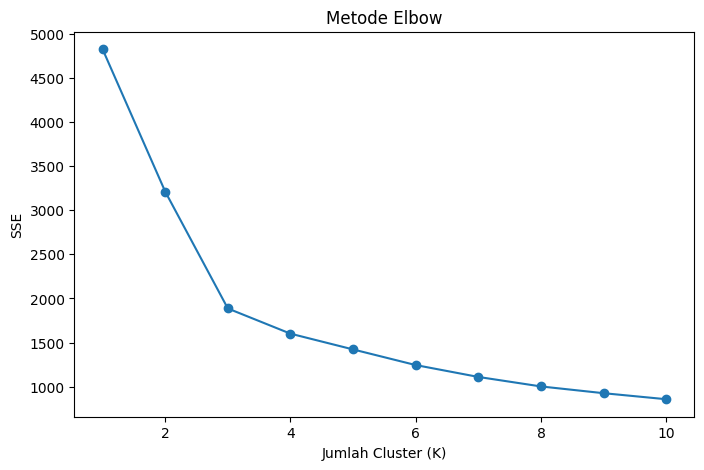

,K,SSE
0,1,"4,823.6308"
1,2,"3,210.3657"
2,3,"1,885.9122"
3,4,"1,600.4850"
4,5,"1,421.8102"
5,6,"1,244.6400"
6,7,"1,110.1147"
7,8,"1,002.5021"
8,9,925.9484
9,10,857.6445


In [ ]:
inertia = []
K_range = range(1,11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_norm)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('SSE')
plt.title('Metode Elbow')
plt.show()

sse_table = pd.DataFrame({'K': list(K_range), 'SSE': inertia})
sse_table

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_norm)

df_cluster_result = fitur_gempa.copy()
df_cluster_result['cluster_label'] = labels

df_cluster_result.head()

,Magnitude,Depth (km),Azimuth Gap,cluster_label
0,4.8480,50,123.7005,0
1,3.4545,10,173.4820,1
2,4.1108,142,106.1382,2
3,4.1585,207,109.2949,2
4,4.3291,57,73.8748,0


In [ ]:
from IPython.display import display

print("===== 5 Data Awal =====")
display(df_cluster_result.head())

print("===== 5 Data Akhir =====")
display(df_cluster_result.tail())

===== 5 Data Awal =====


,Magnitude,Depth (km),Azimuth Gap,cluster_label
0,4.8480,50,123.7005,0
1,3.4545,10,173.4820,1
2,4.1108,142,106.1382,2
3,4.1585,207,109.2949,2
4,4.3291,57,73.8748,0


===== 5 Data Akhir =====


,Magnitude,Depth (km),Azimuth Gap,cluster_label
63775,2.9665,99,109.6918,2
63776,3.0823,1,83.9769,0
63777,3.4910,97,169.1919,2
63778,2.6438,25,221.3553,1
63779,3.2645,1,92.0944,0


In [ ]:
df_cluster_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63780 entries, 0 to 63779
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Magnitude      63780 non-null  float64
 1   Depth (km)     63780 non-null  int64  
 2   Azimuth Gap    63780 non-null  float64
 3   cluster_label  63780 non-null  int32  
dtypes: float64(2), int32(1), int64(1)
memory usage: 1.7 MB


## 10. Evaluasi Hasil

Tahap ini menilai kualitas klaster yang terbentuk dan menginterpretasikannya secara wilayah.


In [ ]:
cluster_counts = (
    df_cluster_result['cluster_label']
    .value_counts()
    .sort_index()
)
cluster_counts

,count
cluster_label,
0,30726
1,23146
2,9908


In [ ]:
cluster_summary = (
    df_cluster_result.groupby('cluster_label')
    [['Magnitude','Depth (km)','Azimuth Gap']]
    .mean()
)
cluster_summary

,Magnitude,Depth (km),Azimuth Gap
cluster_label,,,
0,3.2749,19.9458,95.2163
1,3.2366,20.4147,204.9490
2,3.6812,147.0366,111.7575


In [ ]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Magnitude','Depth (km)','Azimuth Gap']
)
centroids

,Magnitude,Depth (km),Azimuth Gap
0,0.4003,0.0665,0.2522
1,0.3954,0.0681,0.5718
2,0.4531,0.4903,0.3004


,K,Silhouette Score,Davies-Bouldin Index
0,2,0.4337,1.0167
1,3,0.4115,0.8658
2,4,0.3166,1.0235
3,5,0.2902,1.0713
4,6,0.2877,1.1616
5,7,0.2937,1.1017
6,8,0.2941,1.0621
7,9,0.2991,1.0350
8,10,0.2775,1.0293


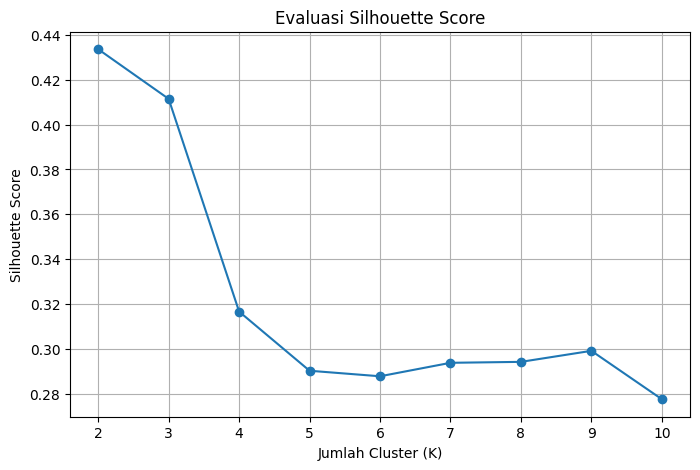

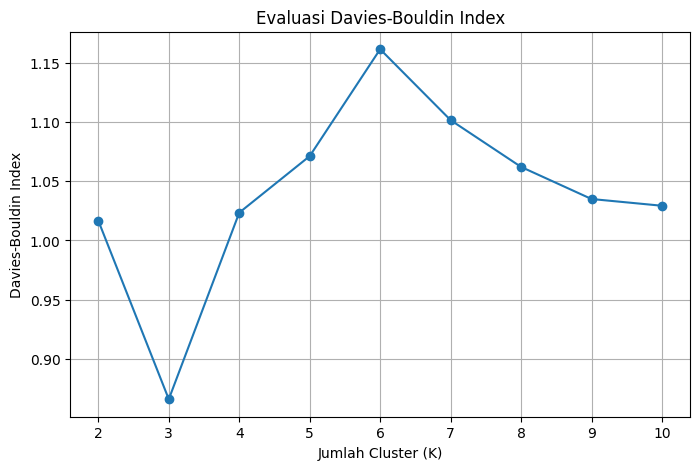

In [ ]:
k_values = range(2, 11)

sil_scores = []
dbi_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_norm)

    sil_scores.append(
        silhouette_score(df_norm, labels)
    )

    dbi_scores.append(
        davies_bouldin_score(df_norm, labels)
    )
scores_table = pd.DataFrame({
    'K': list(k_values),
    'Silhouette Score': sil_scores,
    'Davies-Bouldin Index': dbi_scores
})
display(scores_table)
# Grafik Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Evaluasi Silhouette Score')
plt.grid(True)
plt.show()

# Grafik Davies Bouldin Index
plt.figure(figsize=(8,5))
plt.plot(k_values, dbi_scores, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Evaluasi Davies-Bouldin Index')
plt.grid(True)
plt.show()

In [ ]:
# ================================================
# FINALISASI HASIL CLUSTERING (k=3) — taruh setelah bagian Evaluasi
# ================================================
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(df_norm)   # nama beda, tidak akan ketimpa

# Tempelkan label cluster ke data yang punya info wilayah
df_preprocessed['cluster_label'] = labels_final

# 1) Berapa total gempa di tiap cluster
print("Jumlah total kejadian gempa per cluster:")
display(df_preprocessed['cluster_label'].value_counts().sort_index())

# 2) Provinsi mana yang dominan di tiap cluster (top 5 tiap cluster)
tabel_wilayah_cluster = (
    df_preprocessed.groupby('cluster_label')['Provinsi']
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name='Jumlah_Kejadian')
)
print("\nTabel wilayah dominan per cluster:")
display(tabel_wilayah_cluster)

# 3) Karakteristik rata-rata tiap cluster (untuk interpretasi)
karakteristik_cluster = (
    df_preprocessed.groupby('cluster_label')[['Magnitude','Depth (km)','Azimuth Gap']]
    .mean()
    .round(2)
)
print("\nKarakteristik rata-rata tiap cluster:")
display(karakteristik_cluster)

Jumlah total kejadian gempa per cluster:


,count
cluster_label,
0,30726
1,23146
2,9908



Tabel wilayah dominan per cluster:


,cluster_label,Provinsi,Jumlah_Kejadian
0,0,Sulawesi Tengah,2822
1,0,Sulawesi Selatan,1888
2,0,Papua,1255
3,0,Aceh,1073
4,0,Jawa Barat,909
5,1,Papua,788
6,1,Nusa Tenggara Timur,579
7,1,Nusa Tenggara Barat,475
8,1,Sulawesi Tengah,385
9,1,Aceh,376



Karakteristik rata-rata tiap cluster:


,Magnitude,Depth (km),Azimuth Gap
cluster_label,,,
0,3.2700,19.9500,95.2200
1,3.2400,20.4100,204.9500
2,3.6800,147.0400,111.7600


In [ ]:
output_path = '/content/drive/MyDrive/SKRIPSI/Data Gempa/df_final_fix_terbaru.xlsx'
df_preprocessed.to_excel(output_path, index=False)
print(f"DataFrame berhasil disimpan ke: {output_path}")

DataFrame berhasil disimpan ke: /content/drive/MyDrive/SKRIPSI/Data Gempa/df_final_fix_terbaru.xlsx


## 11. Visualisasi

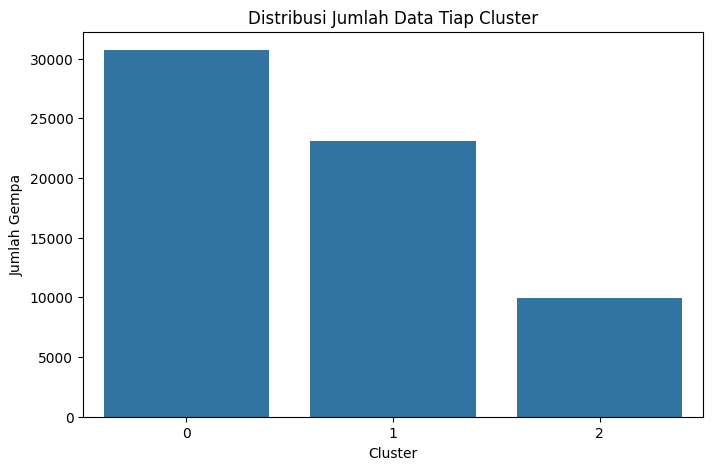

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_counts = (
    df_cluster_result['cluster_label']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Distribusi Jumlah Data Tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Gempa')

plt.show()

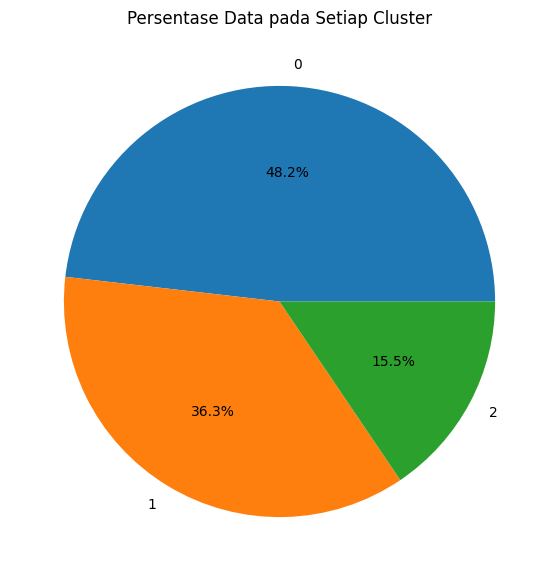

In [ ]:
cluster_counts = df_cluster_result['cluster_label'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%'
)

plt.title('Persentase Data pada Setiap Cluster')

plt.show()

In [ ]:
cluster_summary = (
    df_cluster_result.groupby('cluster_label')
    .agg({
        'Magnitude':['mean','min','max'],
        'Depth (km)':['mean','min','max'],
        'Azimuth Gap':['mean','min','max']
    })
)

cluster_summary.round(2)

Magnitude               Depth (km)          Azimuth Gap  \
                   mean    min    max       mean min  max        mean   
cluster_label                                                           
0                3.2700 0.9500 7.8900    19.9500   1   94     95.2200   
1                3.2400 0.1900 7.0900    20.4100   0  172    204.9500   
2                3.6800 1.0800 7.7400   147.0400  73  300    111.7600   

                                 
                   min      max  
cluster_label                    
0               8.6100 151.6400  
1             148.6500 351.9500  
2               8.8200 337.8500

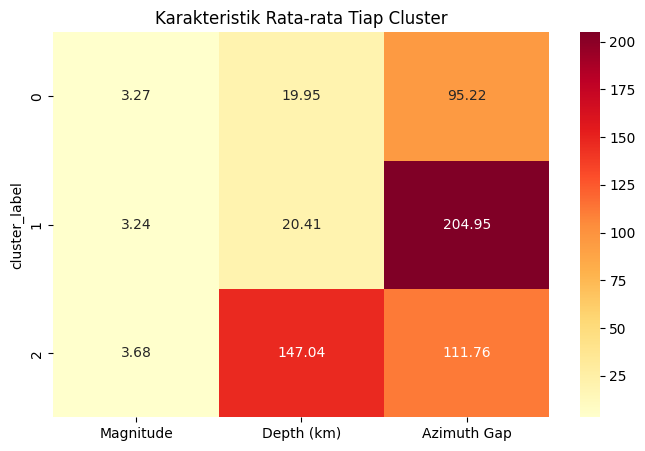

In [ ]:
cluster_mean = (
    df_cluster_result.groupby('cluster_label')
    [['Magnitude',
      'Depth (km)',
      'Azimuth Gap']]
    .mean()
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='YlOrRd',
    fmt='.2f'
)

plt.title('Karakteristik Rata-rata Tiap Cluster')

plt.show()

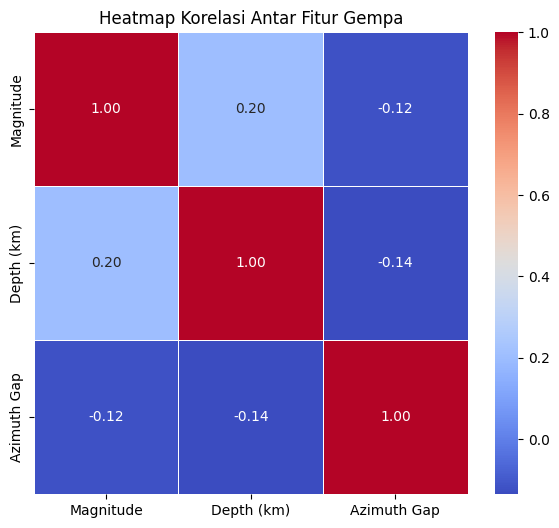

In [ ]:
correlation_matrix = df_cluster_result[['Magnitude', 'Depth (km)', 'Azimuth Gap']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)

plt.title('Heatmap Korelasi Antar Fitur Gempa')
plt.show()

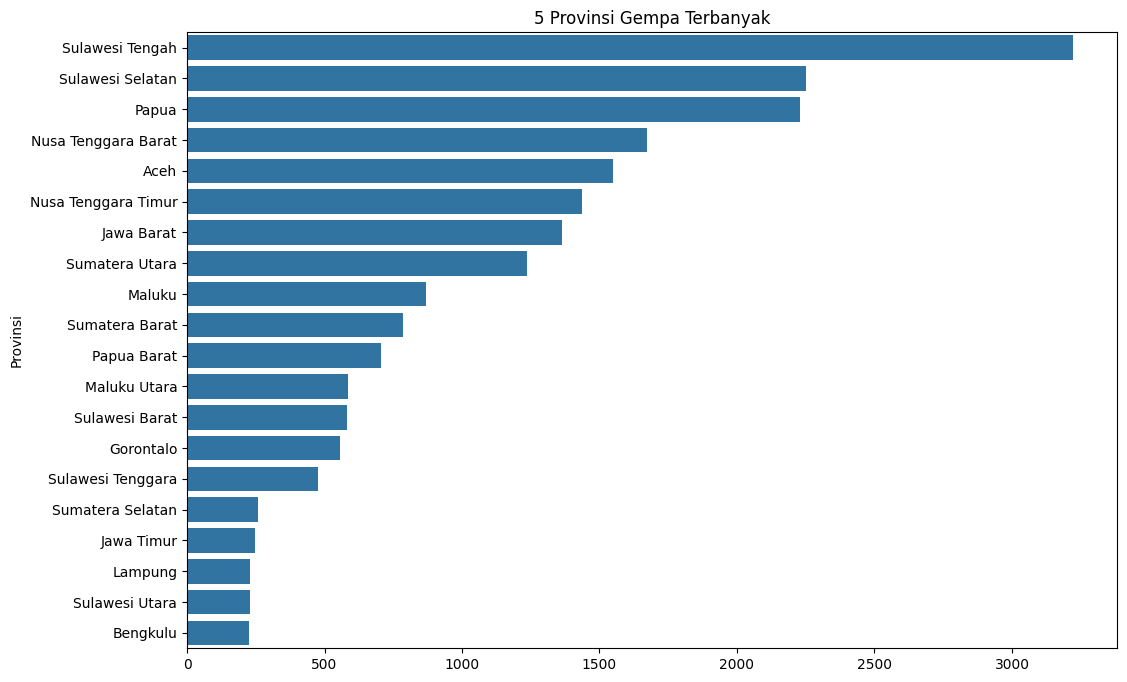

In [ ]:
top_location = (
    df_preprocessed['Provinsi']
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_location.values,
    y=top_location.index
)

plt.title('5 Provinsi Gempa Terbanyak')

plt.show()

## 🔴 Selesai